# Notebook 15 — K-Means para perfiles territoriales

## Finalidad

En este notebook usamos K-Means para identificar perfiles territoriales a partir de `PC1`, `PC2` y `PC3`, obtenidos en el Notebook 14.

Trabajamos con **22 territorios y 3 componentes**, que resumen el **74,54 % de la varianza** de las 19 variables usadas en el PCA.

Nuestros objetivos son:

1. comparar diferentes números de clústeres;
2. seleccionar una solución estable e interpretable;
3. caracterizar los grupos mediante las 19 variables estandarizadas utilizadas en el PCA;
4. comprobar cómo se integran los casos singulares detectados con Isolation Forest;
5. preparar las salidas para los siguientes análisis y para Power BI.

## Criterios metodológicos

El modelo principal se ajusta con `PC1`, `PC2` y `PC3`. Las variables estandarizadas del PCA y los resultados de Isolation Forest los usamos después para interpretar y comprobar la estabilidad de los perfiles, pero no forman parte de las variables de ajuste de K-Means.

Comparamos valores de `k` entre 2 y 6 mediante:

* Silhouette;
* Calinski-Harabasz;
* Davies-Bouldin;
* inercia;
* tamaño de los clústeres;
* estabilidad frente a distintas semillas;
* sensibilidad mediante una prueba *leave-one-out*.

Evitamos soluciones con clústeres formados por un único territorio y no elegimos `k` basándonos en una sola métrica.

No aplicamos un nuevo escalado a `PC1`, `PC2` y `PC3`, ya que queremos conservar la importancia relativa recogida por la varianza explicada de cada componente.

Tampoco eliminamos automáticamente los territorios singulares. Mantenemos los 22 territorios en el modelo principal y las exclusiones temporales las usamos únicamente como pruebas de sensibilidad.

Debido al reducido tamaño de la muestra, interpretamos los resultados como una **tipología territorial exploratoria**, no como una clasificación absoluta ni como un ranking de idoneidad.

In [1]:
# Importaciones, parámetros y rutas
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    davies_bouldin_score,
    silhouette_score,
)

RANDOM_STATE = 42
N_INIT = 100
K_VALUES = range(2, 7)
SEEDS = [13, 21, 42, 73, 101, 137, 211, 307, 401, 503]
MIN_CLUSTER_SIZE = 2
SINGULARITY_THRESHOLD = 0.75
INPUT_ROOT = Path("/kaggle/input")
OUTPUT_DIR = Path(
    "/kaggle/working/salidas_notebook_15_kmeans"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def localizar_archivo(nombre):
    rutas = list(INPUT_ROOT.rglob(nombre))
    if len(rutas) != 1:
        raise FileNotFoundError(
            f"Se esperaba un archivo '{nombre}' y hay {len(rutas)}."
        )
    return rutas[0]

# Salidas definitivas del Notebook 14.
SCORES_PATH = localizar_archivo(
    "puntuaciones_territoriales_pca.csv"
)
PCA_SUMMARY_PATH = localizar_archivo(
    "resumen_pca_final.csv"
)
LOADINGS_PATH = localizar_archivo(
    "cargas_pca.csv"
)
PCA_ISO_PATH = localizar_archivo(
    "integracion_pca_isolation_forest.csv"
)

# Matriz definitiva del Notebook 12.
MATRIZ_PATH = localizar_archivo(
    "matriz_estandarizada_22x25.csv"
)
print("Entradas localizadas: 5")
print("Puntuaciones PCA:", SCORES_PATH)
print("Matriz NB12:", MATRIZ_PATH)
print("Integración PCA-IF:", PCA_ISO_PATH)
print("Salida NB15:", OUTPUT_DIR)


Entradas localizadas: 5
Puntuaciones PCA: /kaggle/input/datasets/aemjeloy/salidas-14/puntuaciones_territoriales_pca.csv
Matriz NB12: /kaggle/input/datasets/aemjeloy/salidas-ntb12/matriz_estandarizada_22x25.csv
Integración PCA-IF: /kaggle/input/datasets/aemjeloy/salidas-14/integracion_pca_isolation_forest.csv
Salida NB15: /kaggle/working/salidas_notebook_15_kmeans


## Carga y comprobación de las entradas

Cargamos las puntuaciones de `PC1`, `PC2` y `PC3` obtenidas en el Notebook 14.

También recuperamos:

* las 19 variables utilizadas en el PCA;
* la matriz estandarizada del Notebook 12;
* la integración entre PCA e Isolation Forest.

Comprobamos que las tablas contienen los mismos 22 territorios, sin duplicados ni valores ausentes.

K-Means se ajustará únicamente con `PC1`, `PC2` y `PC3`. Usaremos las demás variables se para interpretar los clústeres.


In [2]:
# Carga y comprobación de las entradas
scores_df = pd.read_csv(SCORES_PATH)
pca_summary = pd.read_csv(PCA_SUMMARY_PATH)
loadings = pd.read_csv(LOADINGS_PATH)
matriz_nb12 = pd.read_csv(MATRIZ_PATH)
pca_iso = pd.read_csv(PCA_ISO_PATH)

ID_COLS = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
]
PCS = ["PC1", "PC2", "PC3"]

columnas_iso_necesarias = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "score_anomalia",
    "singular",
    "frecuencia",
    "ranking_singularidad",
]

variables_pca = loadings["variable"].tolist()
codigos_scores = set(scores_df["codigo_geo"])

varianza_3pc = pca_summary[
    "varianza_explicada_pct"
].sum()

correcto_01a = (
    scores_df.shape == (22, 6)
    and matriz_nb12.shape == (22, 25)
    and len(variables_pca) == 19
    and len(set(variables_pca)) == 19
    and pca_summary["componente"].is_unique
    and set(pca_summary["componente"]) == set(PCS)
    and set(variables_pca).issubset(matriz_nb12.columns)
    and set(columnas_iso_necesarias).issubset(pca_iso.columns)
    and codigos_scores == set(matriz_nb12["codigo_geo"])
    and codigos_scores == set(pca_iso["codigo_geo"])
    and scores_df["codigo_geo"].is_unique
    and matriz_nb12["codigo_geo"].is_unique
    and pca_iso["codigo_geo"].is_unique
    and not scores_df[ID_COLS + PCS].isna().any().any()
    and not matriz_nb12[
        ID_COLS + variables_pca
    ].isna().any().any()
    and not pca_iso[
        columnas_iso_necesarias
    ].isna().any().any()
    and np.isfinite(
        scores_df[PCS].to_numpy()
    ).all()
    and np.isfinite(
        matriz_nb12[variables_pca].to_numpy()
    ).all()
    and np.isfinite(varianza_3pc)
)

if not correcto_01a:
    raise ValueError(
        "Las entradas del Notebook 15 necesitan revisión."
    )

print(
    "Matriz K-Means:", scores_df[PCS].shape,
    "| Variables PCA:", len(variables_pca),
    "| Varianza:", f"{varianza_3pc:.2f} %",
)

display(scores_df.head())

Matriz K-Means: (22, 3) | Variables PCA: 19 | Varianza: 74.54 %


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3
0,ES11,Galicia,España,2.658738,-1.962831,-2.274198
1,ES12,Principado de Asturias,España,2.050442,-3.168327,-0.547695
2,ES13,Cantabria,España,2.522784,-3.212395,0.001260
3,ES21,País Vasco,España,3.438880,-2.544588,1.386473
4,ES22,Comunidad Foral de Navarra,España,0.211690,-2.999811,0.102952


## Identificación de los territorios singulares

Recuperamos la información de Isolation Forest que quedó integrada en el Notebook 14.

Distinguimos entre:

* **singular en el modelo de referencia**: territorio señalado con `contamination = 0.10`;
* **singularidad estable**: territorio detectado en al menos el 75 % de las semillas evaluadas.

Esta diferencia nos permite separar los casos detectados por el modelo base de aquellos que muestran una mayor estabilidad.

Las singularidades se utilizan únicamente como información complementaria. No intervienen como variables de K-Means y no eliminamos ningún territorio: el clustering se realiza con los 22 casos.


In [3]:
# Identificación de singularidades
pca_iso["singularidad_estable"] = (
    pca_iso["frecuencia"] >= SINGULARITY_THRESHOLD
)
columnas_singularidad = [
    "codigo_geo",
    "nombre_territorio",
    "pais",
    "score_anomalia",
    "singular",
    "frecuencia",
    "singularidad_estable",
    "ranking_singularidad",
]
singulares_base = pca_iso.loc[
    pca_iso["singular"] == True,
    columnas_singularidad,
].copy()

singulares_estables = pca_iso.loc[
    pca_iso["singularidad_estable"] == True,
    columnas_singularidad,
].copy()

codigos_singulares_base = (
    singulares_base["codigo_geo"].tolist()
)
codigos_singulares_estables = (
    singulares_estables["codigo_geo"].tolist()
)
correcto_02a = (
    len(singulares_base) == 3
    and len(singulares_estables) == 2
    and set(codigos_singulares_estables).issubset(
        codigos_singulares_base
    )
)
if not correcto_02a:
    raise ValueError(
        "Las singularidades del Notebook 13 necesitan revisión."
    )
print(
    "Modelo base:", len(singulares_base),
    "| Estables:", len(singulares_estables),
)

display(
    singulares_base.sort_values("ranking_singularidad")
)

Modelo base: 3 | Estables: 2


,codigo_geo,nombre_territorio,pais,score_anomalia,singular,frecuencia,singularidad_estable,ranking_singularidad
0,PT1A,Grande Lisboa,Portugal,0.040798,True,1.0,True,1
1,PT1B,Península de Setúbal,Portugal,0.001776,True,0.8,True,2
2,ES30,Comunidad de Madrid,España,0.000113,True,0.6,False,3


## Evaluación inicial con los 22 territorios

Aplicamos K-Means sobre `PC1`, `PC2` y `PC3`, manteniendo los 22 territorios.

Evaluamos soluciones entre `k = 2` y `k = 6` mediante:

* Silhouette;
* Calinski-Harabasz;
* Davies-Bouldin;
* inercia;
* tamaño mínimo y máximo de los clústeres.

En esta primera evaluación comprobamos si alguna solución genera grupos unitarios o excesivamente pequeños.

Los resultados de Isolation Forest no intervienen en el ajuste. Los utilizaremos después para comprobar cómo se distribuyen los casos singulares entre los perfiles obtenidos.


In [4]:
# Evaluación inicial de K-Means
X_kmeans = scores_df[PCS]

resultados = []
for k in K_VALUES:
    modelo = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
    )
    etiquetas = modelo.fit_predict(X_kmeans)
    tamanos = pd.Series(etiquetas).value_counts()
    resultados.append({
        "k": k,
        "inercia": modelo.inertia_,
        "silhouette": silhouette_score(
            X_kmeans, etiquetas
        ),
        "calinski_harabasz": (
            calinski_harabasz_score(
                X_kmeans, etiquetas
            )
        ),
        "davies_bouldin": davies_bouldin_score(
            X_kmeans, etiquetas
        ),
        "tamano_minimo": int(tamanos.min()),
        "tamano_maximo": int(tamanos.max()),
    })
metricas_k = pd.DataFrame(resultados)
metricas_k["admisible"] = (
    metricas_k["tamano_minimo"]
    >= MIN_CLUSTER_SIZE
)

if metricas_k.shape[0] != 5:
    raise ValueError(
        "La evaluación de K-Means necesita revisión."
    )
metricas_k.to_csv(
    OUTPUT_DIR / "metricas_kmeans.csv",
    index=False,
)

print(
    "Soluciones:", len(metricas_k),
    "| Admisibles:", int(metricas_k["admisible"].sum()),
)

display(metricas_k.round(3))

Soluciones: 5 | Admisibles: 5


,k,inercia,silhouette,calinski_harabasz,davies_bouldin,tamano_minimo,tamano_maximo,admisible
0,2,205.392,0.275,10.338,1.293,10,12,True
1,3,132.366,0.332,12.861,0.995,5,9,True
2,4,97.642,0.346,13.145,0.800,3,9,True
3,5,74.158,0.330,13.605,0.872,2,6,True
4,6,52.929,0.379,15.636,0.720,2,5,True


### Primera lectura de las métricas

Las cinco soluciones cumplen el tamaño mínimo establecido y ninguna genera clústeres unitarios.

Según las métricas internas, `k = 6` presenta el mejor resultado:

* mayor Silhouette (`0,379`);
* mayor Calinski-Harabasz (`15,636`);
* menor Davies-Bouldin (`0,720`).

Sin embargo, esta solución contiene clústeres de solo dos territorios y puede resultar demasiado fragmentada para una muestra de 22 casos.

`k = 4` ofrece una solución más sencilla y equilibrada, aunque sus métricas son algo inferiores.

Por tanto, todavía no fijamos el número definitivo de clústeres. Antes comprobaremos la estabilidad de las distintas soluciones y su capacidad de ofrecer perfiles territoriales interpretables.


## Estabilidad de las soluciones

Las métricas internas favorecen inicialmente `k = 6`, pero necesitamos comprobar si los grupos son suficientemente estables.

Analizamos la estabilidad de cada valor de `k` de dos formas:

1. **Distintas semillas:** comprobamos si la inicialización aleatoria de K-Means modifica la partición.
2. **Exclusión de un territorio:** repetimos el modelo retirando temporalmente un territorio cada vez para comprobar si la solución depende demasiado de casos concretos.

Utilizamos el **Adjusted Rand Index (ARI)** para comparar las particiones. Un valor próximo a `1` indica que las agrupaciones son muy similares.

Los tres territorios señalados por el modelo base de Isolation Forest permanecen en el modelo principal. La exclusión temporal se utiliza únicamente como prueba de sensibilidad y no elimina ningún territorio del resultado definitivo.


In [5]:
# Estabilidad frente a distintas semillas
registros_ari = []
for k in K_VALUES:
    etiquetas_semillas = {}

    for semilla in SEEDS:
        modelo = KMeans(
            n_clusters=k,
            n_init=N_INIT,
            random_state=semilla,
        )
        etiquetas_semillas[semilla] = (
            modelo.fit_predict(X_kmeans)
        )

    for i in range(len(SEEDS)):
        for j in range(i + 1, len(SEEDS)):
            semilla_1 = SEEDS[i]
            semilla_2 = SEEDS[j]
            registros_ari.append({
                "k": k,
                "semilla_1": semilla_1,
                "semilla_2": semilla_2,
                "ari": adjusted_rand_score(
                    etiquetas_semillas[semilla_1],
                    etiquetas_semillas[semilla_2],
                ),
            })
            
estabilidad_semillas = pd.DataFrame(registros_ari)
resumen_semillas = (
    estabilidad_semillas
    .groupby("k")["ari"]
    .agg(
        ari_medio="mean",
        ari_minimo="min",
        ari_maximo="max",
    )
    .reset_index()
)
if estabilidad_semillas.shape[0] != 225:
    raise ValueError(
        "La estabilidad entre semillas necesita revisión."
    )
estabilidad_semillas.to_csv(
    OUTPUT_DIR / "estabilidad_semillas_ari.csv",
    index=False,
)
resumen_semillas.to_csv(
    OUTPUT_DIR / "resumen_estabilidad_semillas.csv",
    index=False,
)
print(
    "Comparaciones:", len(estabilidad_semillas),
    "| Valores de k:", resumen_semillas["k"].nunique(),
)

display(resumen_semillas.round(3))

Comparaciones: 225 | Valores de k: 5


,k,ari_medio,ari_minimo,ari_maximo
0,2,1.000,1.000,1.0
1,3,1.000,1.000,1.0
2,4,1.000,1.000,1.0
3,5,0.944,0.719,1.0
4,6,1.000,1.000,1.0


### Estabilidad frente a la inicialización

Las soluciones con `k = 2`, `k = 3`, `k = 4` y `k = 6` presentan un ARI de `1,000`, por lo que no cambian al utilizar distintas semillas.

La solución con `k = 5` muestra una estabilidad algo menor, con un ARI medio de `0,944` y un mínimo de `0,719`.

Estos resultados refuerzan inicialmente la solución `k = 6`, que combina las mejores métricas internas con una estabilidad completa frente a la inicialización.

Sin embargo, un ARI igual a `1` entre semillas no demuestra que la agrupación sea estable ante cambios en la muestra. Por ello, realizamos una segunda comprobación retirando temporalmente un territorio cada vez.


### Sensibilidad ante la exclusión de un territorio

La estabilidad entre semillas comprueba la influencia de la inicialización aleatoria, pero no la dependencia de territorios concretos.

Para evaluar esta segunda cuestión aplicamos una prueba *leave-one-out*: retiramos temporalmente un territorio, repetimos K-Means con los 21 restantes y comparamos la nueva partición con la solución obtenida sobre esos mismos territorios en el modelo completo.

Repetimos el procedimiento para los 22 territorios y para cada valor de `k`.

Utilizamos nuevamente el ARI. Cuanto más próximo sea a `1`, menor será el cambio producido al retirar una observación.

Esta prueba no elimina territorios de la solución definitiva; únicamente mide la sensibilidad de cada alternativa.


In [6]:
# Sensibilidad al retirar un territorio
X_array = X_kmeans.to_numpy()

resultados_loo = []
for k in K_VALUES:
    etiquetas_base = KMeans(
        n_clusters=k,
        n_init=N_INIT,
        random_state=RANDOM_STATE,
    ).fit_predict(X_array)

    for i in range(len(X_array)):
        mascara = np.arange(len(X_array)) != i
        etiquetas_loo = KMeans(
            n_clusters=k,
            n_init=N_INIT,
            random_state=RANDOM_STATE,
        ).fit_predict(X_array[mascara])
        resultados_loo.append({
            "k": k,
            "codigo_excluido": scores_df.loc[
                i, "codigo_geo"
            ],
            "territorio_excluido": scores_df.loc[
                i, "nombre_territorio"
            ],
            "ari": adjusted_rand_score(
                etiquetas_base[mascara],
                etiquetas_loo,
            ),
        })
estabilidad_loo = pd.DataFrame(resultados_loo)
resumen_loo = (
    estabilidad_loo
    .groupby("k")["ari"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

if len(estabilidad_loo) != 110:
    raise ValueError("La sensibilidad necesita revisión.")
estabilidad_loo.to_csv(
    OUTPUT_DIR / "estabilidad_leave_one_out.csv",
    index=False,
)
resumen_loo.to_csv(
    OUTPUT_DIR / "resumen_estabilidad_leave_one_out.csv",
    index=False,
)

print("Pruebas:", len(estabilidad_loo))

display(resumen_loo.round(3))

Pruebas: 110


,k,mean,min,max
0,2,0.957,0.809,1.0
1,3,0.941,0.716,1.0
2,4,0.940,0.489,1.0
3,5,0.805,0.392,1.0
4,6,0.943,0.680,1.0


### Interpretación de la sensibilidad

La solución con `k = 2` es la más estable al retirar territorios, pero ofrece una división demasiado general para nuestros objetivos.

Las soluciones con `k = 3`, `k = 4` y `k = 6` presentan una estabilidad media similar, próxima a `0,94`.

Sin embargo, `k = 4` alcanza un ARI mínimo de `0,489`, lo que muestra una mayor sensibilidad ante la retirada de algún territorio concreto. `k = 5` es la alternativa menos estable, con un ARI medio de `0,805` y un mínimo de `0,392`.

La solución con `k = 6` mantiene una estabilidad media elevada (`0,943`) y un ARI mínimo de `0,680`. Además, obtiene los mejores resultados de Silhouette, Calinski-Harabasz y Davies-Bouldin.

Por tanto, `k = 6` se mantiene como la alternativa principal. Antes de cerrar la decisión, reunimos todos los criterios en una tabla y comprobamos la composición de sus clústeres.


## Selección del número de clústeres

Reunimos en una única tabla:

* las métricas internas de cada solución;
* la estabilidad frente a distintas semillas;
* la sensibilidad al retirar un territorio;
* el tamaño mínimo y máximo de los clústeres.

Consideramos mejores los valores altos de Silhouette, Calinski-Harabasz y ARI, y los valores bajos de Davies-Bouldin.

También comprobamos que todos los clústeres tengan al menos dos territorios y evitamos elegir una solución únicamente porque destaque en una sola métrica.

Esta comparación nos permitirá fijar el número de clústeres antes de ajustar el modelo definitivo.


In [7]:
# Comparación y selección de k
comparacion_k = (
    metricas_k
    .merge(
        resumen_semillas.rename(columns={
            "ari_medio": "ari_semillas_medio",
            "ari_minimo": "ari_semillas_minimo",
            "ari_maximo": "ari_semillas_maximo",
        }),
        on="k",
    )
    .merge(
        resumen_loo.rename(columns={
            "mean": "ari_loo_medio",
            "min": "ari_loo_minimo",
            "max": "ari_loo_maximo",
        }),
        on="k",
    )
)

# Decisión basada en el conjunto de criterios.
K_SELECCIONADO = 6
fila_seleccionada = comparacion_k.loc[
    comparacion_k["k"] == K_SELECCIONADO
].iloc[0]

if not fila_seleccionada["admisible"]:
    raise ValueError(
        "La solución seleccionada no es admisible."
    )
comparacion_k.to_csv(
    OUTPUT_DIR / "comparacion_candidatos_k.csv",
    index=False,
)

print(
    "K seleccionado:", K_SELECCIONADO,
    "| Silhouette:",
    f"{fila_seleccionada['silhouette']:.3f}",
    "| ARI leave-one-out:",
    f"{fila_seleccionada['ari_loo_medio']:.3f}",
)

display(comparacion_k.round(3))

K seleccionado: 6 | Silhouette: 0.379 | ARI leave-one-out: 0.943


,k,inercia,silhouette,calinski_harabasz,davies_bouldin,tamano_minimo,tamano_maximo,admisible,ari_semillas_medio,ari_semillas_minimo,ari_semillas_maximo,ari_loo_medio,ari_loo_minimo,ari_loo_maximo
0,2,205.392,0.275,10.338,1.293,10,12,True,1.000,1.000,1.0,0.957,0.809,1.0
1,3,132.366,0.332,12.861,0.995,5,9,True,1.000,1.000,1.0,0.941,0.716,1.0
2,4,97.642,0.346,13.145,0.800,3,9,True,1.000,1.000,1.0,0.940,0.489,1.0
3,5,74.158,0.330,13.605,0.872,2,6,True,0.944,0.719,1.0,0.805,0.392,1.0
4,6,52.929,0.379,15.636,0.720,2,5,True,1.000,1.000,1.0,0.943,0.680,1.0


### Comparación visual de los candidatos

Representamos por separado Silhouette, Davies-Bouldin y la estabilidad media *leave-one-out*, ya que utilizan escalas diferentes.

La línea roja identifica la solución seleccionada, `k = 6`.


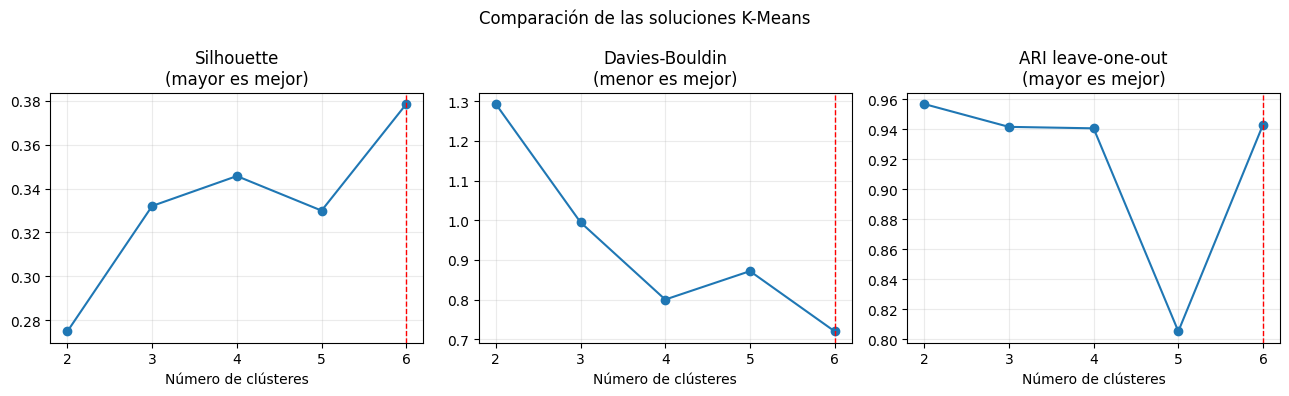

In [8]:
# Comparación visual de los candidatos
graficos = [
    ("silhouette", "Silhouette\n(mayor es mejor)"),
    ("davies_bouldin", "Davies-Bouldin\n(menor es mejor)"),
    ("ari_loo_medio", "ARI leave-one-out\n(mayor es mejor)"),
]
fig, axes = plt.subplots(
    1, 3,
    figsize=(13, 4),
)

for ax, (columna, titulo) in zip(axes, graficos):
    ax.plot(
        comparacion_k["k"],
        comparacion_k[columna],
        marker="o",
    )
    ax.axvline(
        K_SELECCIONADO,
        color="red",
        linestyle="--",
        linewidth=1,
    )
    ax.set_title(titulo)
    ax.set_xlabel("Número de clústeres")
    ax.set_xticks(list(K_VALUES))
    ax.grid(alpha=0.25)
fig.suptitle("Comparación de las soluciones K-Means")
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "comparacion_k_tipologia.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()


## Ajuste final de la tipología

Ajustamos el modelo K-Means definitivo con los **22 territorios**, `PC1`, `PC2`, `PC3` y `k = 6`.

Como los identificadores originales de K-Means son arbitrarios, ordenamos los centroides mediante un criterio fijo para obtener etiquetas reproducibles del perfil 1 al perfil 6.

Después calculamos:

* el centroide de cada perfil;
* el número de territorios de cada grupo;
* la distancia de cada territorio a su centroide.

Los identificadores de los perfiles sirven únicamente para distinguir los grupos. No representan un orden de calidad o idoneidad territorial.


In [9]:
# Ajuste final de K-Means
modelo_final = KMeans(
    n_clusters=K_SELECCIONADO,
    n_init=N_INIT,
    random_state=RANDOM_STATE,
)
etiquetas = modelo_final.fit_predict(X_kmeans)

# Ordenamos los clústeres por sus centroides.
centroides = pd.DataFrame(
    modelo_final.cluster_centers_,
    columns=PCS,
)
orden = centroides.sort_values(
    PCS,
    ascending=False,
).index
mapa_cluster = {
    cluster: posicion + 1
    for posicion, cluster in enumerate(orden)
}

# Resultado territorial.
resultado_tipologia = scores_df[
    ID_COLS + PCS
].copy()
resultado_tipologia["cluster_id"] = [
    mapa_cluster[cluster]
    for cluster in etiquetas
]
distancias = modelo_final.transform(X_kmeans)
resultado_tipologia["distancia_centroide"] = (
    distancias[
        np.arange(len(etiquetas)),
        etiquetas,
    ]
)

# Centroides con la misma numeración.
centroides["cluster_id"] = [
    mapa_cluster[cluster]
    for cluster in centroides.index
]
centroides = centroides.sort_values(
    "cluster_id"
).reset_index(drop=True)
tamanos_finales = (
    resultado_tipologia["cluster_id"]
    .value_counts()
    .sort_index()
)
if (
    len(resultado_tipologia) != 22
    or len(tamanos_finales) != K_SELECCIONADO
    or tamanos_finales.min() < MIN_CLUSTER_SIZE
):
    raise ValueError(
        "La solución final necesita revisión."
    )
resultado_tipologia.to_csv(
    OUTPUT_DIR / "asignacion_perfiles_territoriales.csv",
    index=False,
)
centroides.to_csv(
    OUTPUT_DIR / "centroides_perfiles_pca.csv",
    index=False,
)

print(
    "Clústeres:", len(tamanos_finales),
    "| Tamaños:", tamanos_finales.tolist(),
)

display(centroides.round(3))
display(
    resultado_tipologia.sort_values(
        ["cluster_id", "nombre_territorio"]
    )
)

Clústeres: 6 | Tamaños: [2, 4, 3, 4, 4, 5]


,PC1,PC2,PC3,cluster_id
0,3.671,4.348,0.707,1
1,2.668,-2.722,-0.359,2
2,1.167,1.336,-2.531,3
3,-0.292,0.511,2.315,4
4,-0.969,-2.182,0.126,5
5,-3.294,0.974,-0.430,6


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3,cluster_id,distancia_centroide
18,PT1A,Grande Lisboa,Portugal,4.517965,4.694777,0.981612,1,0.955652
19,PT1B,Península de Setúbal,Portugal,2.823464,4.001210,0.433242,1,0.955652
2,ES13,Cantabria,España,2.522784,-3.212395,0.001260,2,0.625230
0,ES11,Galicia,España,2.658738,-1.962831,-2.274198,2,2.060635
3,ES21,País Vasco,España,3.438880,-2.544588,1.386473,2,1.916054
1,ES12,Principado de Asturias,España,2.050442,-3.168327,-0.547695,2,0.784842
17,PT19,Centro (PT),Portugal,0.519000,0.399069,-2.857328,3,1.185028
15,PT11,Norte,Portugal,2.511666,0.888707,-1.662327,3,1.661986
21,PT1D,Oeste e Vale do Tejo,Portugal,0.470411,2.719988,-3.072559,3,1.641488
11,ES51,Cataluña,España,0.891661,-0.796096,1.427636,4,1.974176


### Primera lectura de la solución

La solución distribuye los 22 territorios en seis perfiles con tamaños de `2`, `4`, `3`, `4`, `4` y `5` casos. Ningún territorio forma un clúster individual.

Grande Lisboa y Península de Setúbal, las dos singularidades más estables de Isolation Forest, forman conjuntamente el perfil 1. Por tanto, no aparecen como casos aislados, sino como un pequeño grupo con características comunes.

Comunidad de Madrid, señalada por el modelo base pero con menor estabilidad, queda integrada en el perfil 4 junto con Cataluña, Comunitat Valenciana y Región de Murcia.

Algarve no aparece como singular en el modelo base definitivo y queda incluido en el perfil 6 con otros territorios.

Los números de perfil solo identifican los grupos y no representan un ranking. Antes de asignarles una interpretación temática, analizamos las variables que caracterizan cada clúster.


### Sensibilidad sin las singularidades estables

Grande Lisboa y Península de Setúbal forman conjuntamente el perfil 1 y son también las dos singularidades estables identificadas mediante Isolation Forest.

Como comprobación adicional, las retiramos temporalmente y repetimos K-Means con `k = 5`. Así comprobamos si los cinco perfiles restantes mantienen su estructura sin estos dos territorios.

Esta prueba no sustituye la solución principal ni elimina territorios de las salidas finales.


In [10]:
# Sensibilidad sin singularidades estables

# Comprobamos qué perfil ocupan las singularidades estables.
perfiles_singulares_estables = (
    resultado_tipologia.loc[
        resultado_tipologia["codigo_geo"].isin(
            codigos_singulares_estables
        ),
        "cluster_id",
    ]
    .drop_duplicates()
    .tolist()
)

if len(perfiles_singulares_estables) != 1:
    raise ValueError(
        "Las singularidades estables no forman un único perfil."
    )

# Retirada temporal de las singularidades estables.
datos_sensibilidad = scores_df.loc[
    ~scores_df["codigo_geo"].isin(
        codigos_singulares_estables
    )
].copy()

X_sensibilidad = datos_sensibilidad[PCS]

# Al retirar un perfil completo, evaluamos los perfiles restantes.
k_sensibilidad = (
    K_SELECCIONADO
    - len(perfiles_singulares_estables)
)

etiquetas_nuevas = KMeans(
    n_clusters=k_sensibilidad,
    n_init=N_INIT,
    random_state=RANDOM_STATE,
).fit_predict(X_sensibilidad)

# Partición original sobre esos mismos territorios.
etiquetas_originales = (
    resultado_tipologia
    .set_index("codigo_geo")
    .loc[
        datos_sensibilidad["codigo_geo"],
        "cluster_id",
    ]
)

ari_sensibilidad = adjusted_rand_score(
    etiquetas_originales,
    etiquetas_nuevas,
)

silhouette_sensibilidad = silhouette_score(
    X_sensibilidad,
    etiquetas_nuevas,
)

tamanos_sensibilidad = sorted(
    pd.Series(etiquetas_nuevas)
    .value_counts()
    .tolist()
)

n_esperado = (
    len(scores_df)
    - len(codigos_singulares_estables)
)

correcto_06b = (
    X_sensibilidad.shape
    == (n_esperado, len(PCS))
    and len(tamanos_sensibilidad) == k_sensibilidad
    and sum(tamanos_sensibilidad) == n_esperado
    and np.isfinite(ari_sensibilidad)
    and np.isfinite(silhouette_sensibilidad)
)

if not correcto_06b:
    raise ValueError(
        "La sensibilidad necesita revisión."
    )

resumen_sensibilidad = pd.DataFrame([{
    "territorios_excluidos":
        " | ".join(codigos_singulares_estables),
    "n_territorios": len(X_sensibilidad),
    "k": k_sensibilidad,
    "ari": ari_sensibilidad,
    "silhouette": silhouette_sensibilidad,
    "tamanos": " | ".join(
        map(str, tamanos_sensibilidad)
    ),
}])

resumen_sensibilidad.to_csv(
    OUTPUT_DIR
    / "sensibilidad_sin_singularidades_estables.csv",
    index=False,
)

print(
    "Excluidos:", codigos_singulares_estables,
    "| Matriz:", X_sensibilidad.shape,
    "| ARI:", f"{ari_sensibilidad:.3f}",
    "| Silhouette:",
    f"{silhouette_sensibilidad:.3f}",
)
print("Tamaños:", tamanos_sensibilidad)

display(resumen_sensibilidad.round(3))

Excluidos: ['PT1A', 'PT1B'] | Matriz: (20, 3) | ARI: 1.000 | Silhouette: 0.354
Tamaños: [3, 4, 4, 4, 5]


,territorios_excluidos,n_territorios,k,ari,silhouette,tamanos
0,PT1A | PT1B,20,5,1.0,0.354,3 | 4 | 4 | 4 | 5


### Interpretación de la sensibilidad

Al retirar temporalmente Grande Lisboa y Península de Setúbal, trabajamos con **20 territorios y cinco perfiles**. La nueva agrupación conserva la misma estructura que la solución original sobre esos mismos territorios, con un `ARI = 1,000`.

Usamos el valor de ARI como **resultado de la prueba de sensibilidad**, no como una condición impuesta por el código. La validación de la celda comprueba solo que la matriz, el número de perfiles y las métricas calculadas sean coherentes y finitas. De esta forma, la prueba podría mostrar cualquier nivel de estabilidad sin forzar un resultado concreto.

La solución obtenida presenta tamaños de `3`, `4`, `4`, `4` y `5` territorios, con un Silhouette de `0,354`.

Estos resultados indican que, en esta comprobación, Grande Lisboa y Península de Setúbal forman un perfil propio  diferenciado, mientras que su retirada no modifica la agrupación de los otros 20 territorios.

Por tanto, mantenemos los **22 territorios y los seis perfiles** en la solución principal. Usamos la exclusión únicamente como prueba de sensibilidad.

## Integración de los casos singulares

Incorporamos a la tipología la información de Isolation Forest que quedó integrada en el Notebook 14.

Distinguimos entre:

* tres territorios señalados por el modelo de referencia;
* dos territorios con singularidad estable frente a distintas semillas.

Los 22 territorios han participado en el ajuste de K-Means y todos conservan un perfil entre 1 y 6, además de una distancia válida a su centroide. Por este motivo no utilizamos un `cluster_id = 0` ni creamos un grupo independiente para los casos singulares.

La tabla final permitirá analizar conjuntamente el perfil territorial y la singularidad multivariante sin eliminar ni duplicar observaciones.


In [11]:
# Integración con Isolation Forest
columnas_iso = [
    "codigo_geo",
    "score_anomalia",
    "singular",
    "veces_singular",
    "frecuencia",
    "cont_05",
    "cont_10",
    "cont_15",
    "n_umbrales",
    "ranking_singularidad",
    "singularidad_estable",
]
info_iso = pca_iso[columnas_iso].rename(
    columns={
        "singular": "singular_modelo_base"
    }
)
resultado_final = resultado_tipologia.merge(
    info_iso,
    on="codigo_geo",
    how="left",
    validate="one_to_one",
)
correcto_07a = (
    len(resultado_final) == 22
    and resultado_final["codigo_geo"].is_unique
    and resultado_final[
        "singular_modelo_base"
    ].sum() == 3
    and resultado_final[
        "singularidad_estable"
    ].sum() == 2
)

if not correcto_07a:
    raise ValueError(
        "La integración con Isolation Forest necesita revisión."
    )
resultado_final.to_csv(
    OUTPUT_DIR / "resultado_kmeans_con_singularidad.csv",
    index=False,
)

print(
    "Territorios:", len(resultado_final),
    "| Modelo base:",
    int(resultado_final["singular_modelo_base"].sum()),
    "| Estables:",
    int(resultado_final["singularidad_estable"].sum()),
)

display(
    resultado_final.sort_values(
        ["cluster_id", "nombre_territorio"]
    )
)

Territorios: 22 | Modelo base: 3 | Estables: 2


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3,cluster_id,distancia_centroide,score_anomalia,singular_modelo_base,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales,ranking_singularidad,singularidad_estable
18,PT1A,Grande Lisboa,Portugal,4.517965,4.694777,0.981612,1,0.955652,0.040798,True,5,1.0,True,True,True,3,1,True
19,PT1B,Península de Setúbal,Portugal,2.823464,4.001210,0.433242,1,0.955652,0.001776,True,4,0.8,True,True,True,3,2,True
2,ES13,Cantabria,España,2.522784,-3.212395,0.001260,2,0.625230,-0.033956,False,0,0.0,False,False,False,0,12,False
0,ES11,Galicia,España,2.658738,-1.962831,-2.274198,2,2.060635,-0.036186,False,0,0.0,False,False,False,0,14,False
3,ES21,País Vasco,España,3.438880,-2.544588,1.386473,2,1.916054,-0.028339,False,0,0.0,False,False,False,0,11,False
1,ES12,Principado de Asturias,España,2.050442,-3.168327,-0.547695,2,0.784842,-0.041994,False,0,0.0,False,False,False,0,15,False
17,PT19,Centro (PT),Portugal,0.519000,0.399069,-2.857328,3,1.185028,-0.053354,False,0,0.0,False,False,False,0,18,False
15,PT11,Norte,Portugal,2.511666,0.888707,-1.662327,3,1.661986,-0.026472,False,0,0.0,False,False,False,0,9,False
21,PT1D,Oeste e Vale do Tejo,Portugal,0.470411,2.719988,-3.072559,3,1.641488,-0.034138,False,0,0.0,False,False,False,0,13,False
11,ES51,Cataluña,España,0.891661,-0.796096,1.427636,4,1.974176,-0.076843,False,0,0.0,False,False,False,0,22,False


## Caracterización de los perfiles

K-Means se ha ajustado únicamente con `PC1`, `PC2` y `PC3`. Para interpretar los seis perfiles recuperamos las **19 variables analíticas estandarizadas** que participaron en el PCA.

Calculamos el valor medio de cada variable dentro de cada clúster:

* un valor positivo indica que el perfil se sitúa por encima de la media de los 22 territorios;
* un valor negativo indica que se sitúa por debajo;
* un valor próximo a cero indica una posición cercana a la media.

Estas diferencias nos ayudan a describir los perfiles, pero no representan una relación causal ni una importancia calculada directamente por K-Means.


In [12]:
# Perfil medio de las variables
variables_perfil = variables_pca.copy()

datos_perfil = matriz_nb12[
    ["codigo_geo"] + variables_perfil
].merge(
    resultado_final[
        ["codigo_geo", "cluster_id"]
    ],
    on="codigo_geo",
    validate="one_to_one",
)
perfil_variables = (
    datos_perfil
    .groupby("cluster_id")[variables_perfil]
    .mean()
    .reset_index()
)
correcto_08a = (
    len(variables_perfil) == 19
    and datos_perfil.shape[0] == 22
    and perfil_variables.shape == (6, 20)
    and not perfil_variables.isna().any().any()
)

if not correcto_08a:
    raise ValueError(
        "La caracterización de los perfiles necesita revisión."
    )
perfil_variables.to_csv(
    OUTPUT_DIR
    / "perfil_variables_estandarizadas_por_cluster.csv",
    index=False,
)

print(
    "Perfiles:", len(perfil_variables),
    "| Variables:", len(variables_perfil),
)

display(perfil_variables.round(2))

Perfiles: 6 | Variables: 19


,cluster_id,densidad_poblacion,nivel_formativo_terciario,corine_compat_media_0_3,logistica_road_alta_capacidad_km_por_1000km2,logistica_places_n_por_1000km2,pvgis_produccion_anual_kwh_kwp,pvgis_perdidas_totales_pct,pvgis_coef_variacion_mensual,ambiental_densidad_sitios_1000km2,ambiental_penalizacion_media_0_1,electrica_densidad_alta_tension_km_1000km2,electrica_densidad_subestaciones_1000km2,digital_data_centers_osm_n,digital_torres_mastiles_1000km2,digital_exchanges_centrales_telecom_1000km2,precipitation_daily_mean_mm_2024_2025,temperatura_media_2m_c,punto_rocio_medio_c,hidrica_wei_area_estres_grave_pct_territorio_2019_2023
0,1,1.88,0.08,1.51,2.03,0.73,0.48,0.45,0.52,-0.11,-0.81,1.86,1.90,0.26,2.20,2.55,-0.40,0.96,1.77,0.23
1,2,0.15,1.05,-1.26,0.16,1.22,-1.81,0.97,0.95,1.13,0.39,0.68,-0.21,0.17,0.00,-0.17,1.48,-1.17,-0.06,-0.98
2,3,-0.04,-1.25,-0.03,0.36,0.85,-0.19,0.00,0.18,-1.16,-1.80,-0.20,1.46,0.33,0.93,-0.46,0.80,0.21,0.61,-0.61
3,4,0.84,0.38,0.44,0.47,-0.57,0.68,-0.24,-1.19,0.49,0.90,0.58,-0.28,0.53,-0.44,0.26,-0.75,0.31,-0.35,-0.28
4,5,-0.84,0.58,0.18,-0.60,-0.56,-0.06,0.54,0.69,0.14,0.40,-0.95,-0.74,-0.26,-0.74,-0.58,-0.10,-1.07,-1.16,-0.25
5,6,-0.85,-0.89,-0.08,-1.05,-0.88,0.88,-1.20,-0.68,-0.66,0.05,-0.87,-0.64,-0.66,-0.49,-0.34,-0.82,1.03,0.18,1.48


### Variables distintivas de cada perfil

Para resumir la tabla anterior seleccionamos, en cada perfil, las cinco variables con mayor valor absoluto.

Conservamos el signo de la media estandarizada:

* un signo positivo indica una posición superior a la media;
* un signo negativo indica una posición inferior;
* el valor absoluto indica la intensidad de la diferencia.

Esta selección es descriptiva y nos ayuda a interpretar los perfiles. No representa una importancia causal ni modifica el modelo K-Means.


In [13]:
# Variables distintivas de cada perfil
familias = loadings.set_index(
    "variable"
)["familia"].to_dict()

registros = []
for _, fila in perfil_variables.iterrows():
    valores = fila[variables_perfil].astype(float)
    principales = valores.abs().nlargest(5).index

    for posicion, variable in enumerate(
        principales,
        start=1,
    ):
        valor = float(valores[variable])
        registros.append({
            "cluster_id": int(fila["cluster_id"]),
            "posicion": posicion,
            "variable": variable,
            "familia": familias[variable],
            "z_medio": valor,
            "direccion": (
                "superior a la media"
                if valor > 0
                else "inferior a la media"
            ),
        })
variables_distintivas = pd.DataFrame(registros)

if len(variables_distintivas) != 30:
    raise ValueError(
        "Las variables distintivas necesitan revisión."
    )
variables_distintivas.to_csv(
    OUTPUT_DIR / "variables_distintivas_por_perfil.csv",
    index=False,
)

print(
    "Perfiles:", variables_distintivas["cluster_id"].nunique(),
    "| Variables por perfil: 5",
)

display(variables_distintivas.round(3))

Perfiles: 6 | Variables por perfil: 5


,cluster_id,posicion,variable,familia,z_medio,direccion
0,1,1,digital_exchanges_centrales_telecom_1000km2,Digital,2.550,superior a la media
1,1,2,digital_torres_mastiles_1000km2,Digital,2.198,superior a la media
2,1,3,logistica_road_alta_capacidad_km_por_1000km2,Logística,2.025,superior a la media
3,1,4,electrica_densidad_subestaciones_1000km2,Eléctrica,1.897,superior a la media
4,1,5,densidad_poblacion,Socioeconómica,1.881,superior a la media
5,2,1,pvgis_produccion_anual_kwh_kwp,PVGIS,-1.812,inferior a la media
6,2,2,precipitation_daily_mean_mm_2024_2025,Climática,1.481,superior a la media
7,2,3,corine_compat_media_0_3,CORINE,-1.256,inferior a la media
8,2,4,logistica_places_n_por_1000km2,Logística,1.224,superior a la media
9,2,5,temperatura_media_2m_c,Climática,-1.171,inferior a la media


### Interpretación inicial de los perfiles

A partir de las variables distintivas y de los territorios incluidos, interpretamos los seis perfiles de la siguiente forma:

* **Perfil 1 · Alta infraestructura metropolitana y digital:** presenta valores elevados de conectividad digital, vías de alta capacidad, subestaciones y densidad de población.
* **Perfil 2 · Húmedo y de menor potencial solar:** combina mayor precipitación y temperaturas más bajas con una producción fotovoltaica inferior a la media.
* **Perfil 3 · Infraestructura eléctrica y menor presión ambiental:** destaca por su densidad de subestaciones y torres digitales, junto con valores inferiores en los indicadores de presión ambiental.
* **Perfil 4 · Urbano, solar y de baja variabilidad:** presenta mayor densidad de población y producción fotovoltaica, con menor precipitación y variabilidad solar mensual.
* **Perfil 5 · Clima más frío y baja densidad:** muestra temperaturas y punto de rocío bajos, además de una menor densidad demográfica, eléctrica y digital.
* **Perfil 6 · Cálido y con estrés hídrico:** combina temperaturas y estrés hídrico elevados con una menor densidad logística.

Estos nombres son etiquetas descriptivas asignadas después de revisar los centroides y las variables distintivas. No los genera automáticamente K-Means y no representan un ranking entre territorios.



In [14]:
# Nombres descriptivos de los perfiles
NOMBRES_PERFIL = {
    1: "Alta infraestructura metropolitana y digital",
    2: "Húmedo y de menor potencial solar",
    3: "Infraestructura eléctrica y menor presión ambiental",
    4: "Urbano, solar y de baja variabilidad",
    5: "Clima más frío y baja densidad",
    6: "Cálido y con estrés hídrico",
}
resultado_final["nombre_perfil"] = (
    resultado_final["cluster_id"].map(NOMBRES_PERFIL)
)
centroides["nombre_perfil"] = (
    centroides["cluster_id"].map(NOMBRES_PERFIL)
)
perfil_variables["nombre_perfil"] = (
    perfil_variables["cluster_id"].map(NOMBRES_PERFIL)
)
variables_distintivas["nombre_perfil"] = (
    variables_distintivas["cluster_id"].map(
        NOMBRES_PERFIL
    )
)
if resultado_final["nombre_perfil"].isna().any():
    raise ValueError(
        "Faltan nombres de perfiles."
    )

# Actualizamos las salidas anteriores.
resultado_final.to_csv(
    OUTPUT_DIR / "resultado_kmeans_con_singularidad.csv",
    index=False,
)
centroides.to_csv(
    OUTPUT_DIR / "centroides_perfiles_pca.csv",
    index=False,
)
perfil_variables.to_csv(
    OUTPUT_DIR
    / "perfil_variables_estandarizadas_por_cluster.csv",
    index=False,
)
variables_distintivas.to_csv(
    OUTPUT_DIR / "variables_distintivas_por_perfil.csv",
    index=False,
)

print("Perfiles nombrados:", len(NOMBRES_PERFIL))


Perfiles nombrados: 6


## Visualización de la tipología

Representamos los 22 territorios y los seis perfiles en el plano formado por `PC1` y `PC2`.

Mostramos también los centroides de cada clúster y destacamos los casos identificados mediante Isolation Forest:

* Grande Lisboa y Península de Setúbal como singularidades estables;
* Comunidad de Madrid como caso señalado por el modelo base, pero con menor estabilidad.

Los casos singulares no forman un grupo independiente, ya que participaron en el ajuste de K-Means y conservan su perfil territorial.

Esta figura es una proyección bidimensional utilizada para facilitar la interpretación. La asignación de los perfiles se ha calculado utilizando conjuntamente `PC1`, `PC2` y `PC3`.


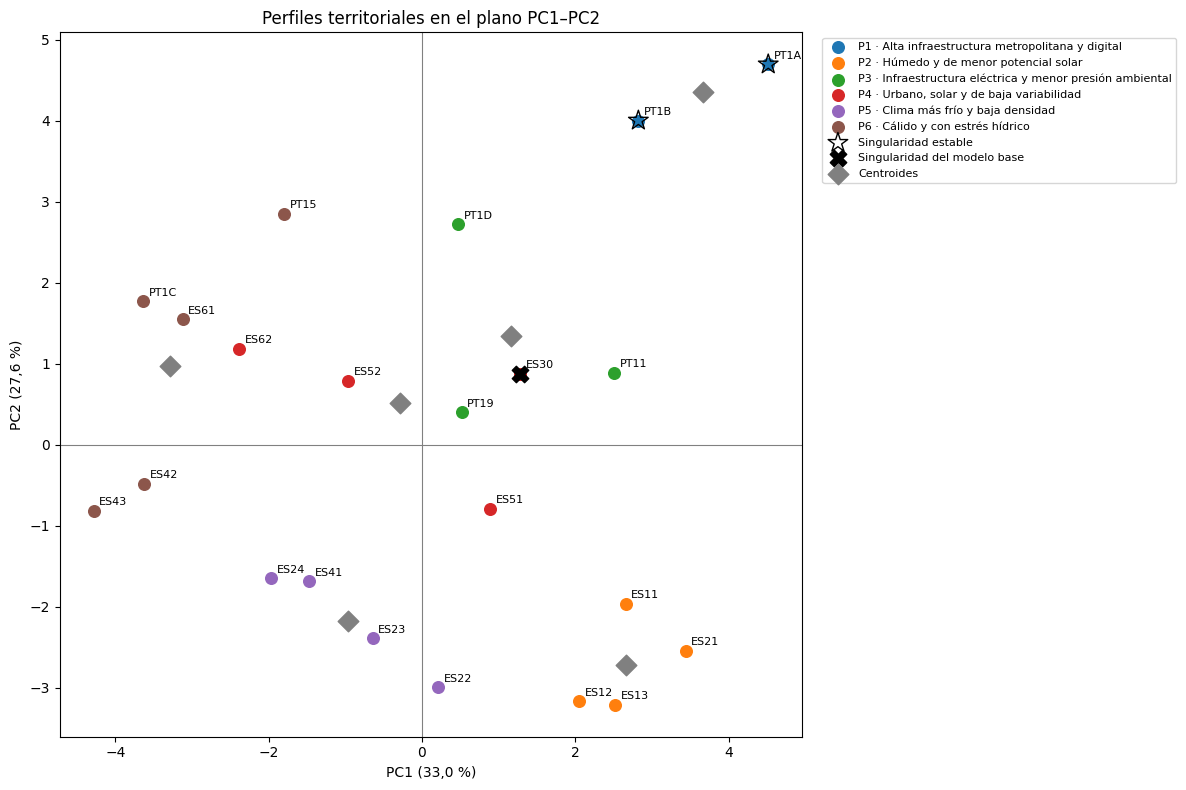

In [15]:
# Visualización de la tipología
fig, ax = plt.subplots(figsize=(12, 8))

# Dibujamos los seis perfiles.
for perfil, grupo in resultado_final.groupby(
    "cluster_id"
):
    nombre = grupo["nombre_perfil"].iloc[0]
    ax.scatter(
        grupo["PC1"],
        grupo["PC2"],
        s=70,
        label=f"P{perfil} · {nombre}",
    )
    for _, fila in grupo.iterrows():
        ax.annotate(
            fila["codigo_geo"],
            (fila["PC1"], fila["PC2"]),
            xytext=(4, 4),
            textcoords="offset points",
            fontsize=8,
        )

# Destacamos los casos singulares.
estables = resultado_final[
    resultado_final["singularidad_estable"] == True
]
menos_estable = resultado_final[
    (resultado_final["singular_modelo_base"] == True)
    & (resultado_final["singularidad_estable"] == False)
]
ax.scatter(
    estables["PC1"],
    estables["PC2"],
    marker="*",
    s=220,
    facecolors="none",
    edgecolors="black",
    label="Singularidad estable",
)
ax.scatter(
    menos_estable["PC1"],
    menos_estable["PC2"],
    marker="X",
    s=140,
    color="black",
    label="Singularidad del modelo base",
)

# Añadimos los centroides.
ax.scatter(
    centroides["PC1"],
    centroides["PC2"],
    marker="D",
    s=110,
    color="grey",
    label="Centroides",
)
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.set_xlabel("PC1 (33,0 %)")
ax.set_ylabel("PC2 (27,6 %)")
ax.set_title("Perfiles territoriales en el plano PC1–PC2")
ax.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
    fontsize=8,
)
plt.tight_layout()
plt.savefig(
    OUTPUT_DIR / "tipologia_pc1_pc2.png",
    dpi=180,
    bbox_inches="tight",
)
plt.show()



### Justificación de la proyección PC1–PC2

La figura anterior utiliza `PC1` y `PC2` porque son los dos componentes que concentran una mayor proporción de la varianza explicada.

`PC1` explica aproximadamente el `33,0 %` y `PC2` el `27,6 %`, por lo que su representación conjunta recoge alrededor del `60,6 %` de la variabilidad resumida por el PCA. Por este motivo, el plano `PC1–PC2` constituye la proyección bidimensional más informativa para visualizar la tipología territorial.

No obstante, el modelo K-Means no lo hemos ajustado solo con estos dos componentes. Hemos calculado la agrupación usando conjuntamente `PC1`, `PC2` y `PC3`, que explican en total el `74,54 %` de la varianza.

Por tanto, la figura `PC1–PC2` debe interpretarse solo como una representación visual en dos dimensiones. Dos territorios próximos en este plano pueden presentar diferencias adicionales en `PC3`, que sí han sido consideradas por el algoritmo durante la formación de los clústeres.

## Síntesis de los perfiles para la memoria
Construimos una tabla resumen de los seis perfiles territoriales obtenidos.

Para cada perfil recogemos:

* su nombre descriptivo;
* el número de territorios;
* los centroides de `PC1`, `PC2` y `PC3`;
* los territorios que lo forman;
* sus principales variables distintivas;
* las distancias media y máxima al centroide;
* los casos señalados por el modelo base de Isolation Forest;
* las singularidades estables.

Esta tabla reúne los principales resultados de K-Means y facilita su posterior utilización en la memoria del proyecto.


In [16]:
# SÍNTESIS DE LOS PERFILES
registros = []
for cluster_id, grupo in resultado_final.groupby("cluster_id"):
    centroide = centroides.loc[
        centroides["cluster_id"].eq(cluster_id)
    ].iloc[0]
    top = variables_distintivas.loc[
        variables_distintivas["cluster_id"].eq(cluster_id)
    ].sort_values("posicion")
    registros.append({
        "cluster_id": int(cluster_id),
        "nombre_perfil": grupo["nombre_perfil"].iloc[0],
        "n_territorios": len(grupo),
        "centroide_PC1": centroide["PC1"],
        "centroide_PC2": centroide["PC2"],
        "centroide_PC3": centroide["PC3"],
        "territorios": " | ".join(
            grupo.sort_values("nombre_territorio")[
                "nombre_territorio"
            ]
        ),
        "variables_distintivas": " | ".join(
            f"{fila.variable} ({fila.z_medio:+.2f})"
            for fila in top.itertuples()
        ),
        "distancia_media": grupo["distancia_centroide"].mean(),
        "distancia_maxima": grupo["distancia_centroide"].max(),
        "n_singulares_base": int(
            grupo["singular_modelo_base"].sum()
        ),
        "n_singularidades_estables": int(
            grupo["singularidad_estable"].sum()
        ),
    })
sintesis_perfiles = pd.DataFrame(registros)
casos_singulares = resultado_final.loc[
    resultado_final["singular_modelo_base"]
].sort_values("ranking_singularidad")

if len(sintesis_perfiles) != 6 or len(casos_singulares) != 3:
    raise ValueError("La síntesis necesita revisión.")

sintesis_perfiles.to_csv(
    OUTPUT_DIR / "sintesis_perfiles_memoria.csv",
    index=False,
)
casos_singulares.to_csv(
    OUTPUT_DIR / "casos_singulares_documentados.csv",
    index=False,
)

print(
    "Perfiles:", len(sintesis_perfiles),
    "| Casos singulares:", len(casos_singulares),
)

display(sintesis_perfiles.round(3))
display(casos_singulares)

Perfiles: 6 | Casos singulares: 3


,cluster_id,nombre_perfil,n_territorios,centroide_PC1,centroide_PC2,centroide_PC3,territorios,variables_distintivas,distancia_media,distancia_maxima,n_singulares_base,n_singularidades_estables
0,1,Alta infraestructura metropolitana y digital,2,3.671,4.348,0.707,Grande Lisboa | Península de Setúbal,digital_exchanges_centrales_telecom_1000km2 (+...,0.956,0.956,2,2
1,2,Húmedo y de menor potencial solar,4,2.668,-2.722,-0.359,Cantabria | Galicia | País Vasco | Principado ...,pvgis_produccion_anual_kwh_kwp (-1.81) | preci...,1.347,2.061,0,0
2,3,Infraestructura eléctrica y menor presión ambi...,3,1.167,1.336,-2.531,Centro (PT) | Norte | Oeste e Vale do Tejo,ambiental_penalizacion_media_0_1 (-1.80) | ele...,1.496,1.662,0,0
3,4,"Urbano, solar y de baja variabilidad",4,-0.292,0.511,2.315,Cataluña | Comunidad de Madrid | Comunitat Val...,pvgis_coef_variacion_mensual (-1.19) | ambient...,1.746,2.197,1,0
4,5,Clima más frío y baja densidad,4,-0.969,-2.182,0.126,Aragón | Castilla y León | Comunidad Foral de ...,punto_rocio_medio_c (-1.16) | temperatura_medi...,1.050,1.436,0,0
5,6,Cálido y con estrés hídrico,5,-3.294,0.974,-0.430,Alentejo | Algarve | Andalucía | Castilla-La M...,hidrica_wei_area_estres_grave_pct_territorio_2...,1.802,2.412,0,0


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3,cluster_id,distancia_centroide,score_anomalia,singular_modelo_base,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales,ranking_singularidad,singularidad_estable,nombre_perfil
18,PT1A,Grande Lisboa,Portugal,4.517965,4.694777,0.981612,1,0.955652,0.040798,True,5,1.0,True,True,True,3,1,True,Alta infraestructura metropolitana y digital
19,PT1B,Península de Setúbal,Portugal,2.823464,4.001210,0.433242,1,0.955652,0.001776,True,4,0.8,True,True,True,3,2,True,Alta infraestructura metropolitana y digital
7,ES30,Comunidad de Madrid,España,1.284564,0.875164,3.512101,4,2.012973,0.000113,True,3,0.6,False,True,True,2,3,False,"Urbano, solar y de baja variabilidad"


## Salida para Power BI
Preparamos una tabla final con una fila por territorio para facilitar la incorporación de los resultados a Power BI.

La salida incluye:

* las puntuaciones de `PC1`, `PC2` y `PC3`;
* el identificador y el nombre descriptivo del perfil;
* la distancia de cada territorio a su centroide;
* el resultado de Isolation Forest;
* y la distinción entre singularidad del modelo base y singularidad estable.

Los nombres de los seis perfiles son etiquetas descriptivas asignadas después de revisar sus centroides y variables distintivas. No son nombres generados automáticamente por K-Means.

Esta tabla permitirá representar territorialmente los perfiles, comparar sus características y combinar posteriormente los resultados con los siguientes notebooks del proyecto.


In [17]:
# Salida para Power BI
powerbi = resultado_final.copy()

# Clasificación descriptiva de la singularidad.
powerbi["tipo_singularidad"] = np.select(
    [
        powerbi["singularidad_estable"],
        powerbi["singular_modelo_base"],
        (powerbi["frecuencia"] > 0)
        | (powerbi["n_umbrales"] > 0),
    ],
    [
        "Singularidad estable",
        "Singularidad del modelo base",
        "Caso sensible a la configuración",
    ],
    default="No singular",
)

n_sensibles_config = int(
    (
        powerbi["tipo_singularidad"]
        == "Caso sensible a la configuración"
    ).sum()
)

correcto_11a = (
    len(powerbi) == len(scores_df)
    and powerbi["codigo_geo"].is_unique
    and set(powerbi["codigo_geo"])
    == set(scores_df["codigo_geo"])
    and powerbi["cluster_id"].nunique()
    == K_SELECCIONADO
    and int(
        powerbi["singular_modelo_base"].sum()
    ) == len(singulares_base)
    and int(
        powerbi["singularidad_estable"].sum()
    ) == len(singulares_estables)
    and not powerbi[
        ["nombre_perfil", "tipo_singularidad"]
    ].isna().any().any()
)

if not correcto_11a:
    raise ValueError(
        "La salida para Power BI necesita revisión."
    )

powerbi.to_csv(
    OUTPUT_DIR / "kmeans_powerbi.csv",
    index=False,
)

print(
    "Territorios:", len(powerbi),
    "| Perfiles:", powerbi["cluster_id"].nunique(),
    "| Singulares base:",
    int(powerbi["singular_modelo_base"].sum()),
    "| Estables:",
    int(powerbi["singularidad_estable"].sum()),
    "| Sensibles:",
    n_sensibles_config,
)

display(
    powerbi.sort_values(
        ["cluster_id", "nombre_territorio"]
    )
)

Territorios: 22 | Perfiles: 6 | Singulares base: 3 | Estables: 2 | Sensibles: 1


,codigo_geo,nombre_territorio,pais,PC1,PC2,PC3,cluster_id,distancia_centroide,score_anomalia,singular_modelo_base,veces_singular,frecuencia,cont_05,cont_10,cont_15,n_umbrales,ranking_singularidad,singularidad_estable,nombre_perfil,tipo_singularidad
18,PT1A,Grande Lisboa,Portugal,4.517965,4.694777,0.981612,1,0.955652,0.040798,True,5,1.0,True,True,True,3,1,True,Alta infraestructura metropolitana y digital,Singularidad estable
19,PT1B,Península de Setúbal,Portugal,2.823464,4.001210,0.433242,1,0.955652,0.001776,True,4,0.8,True,True,True,3,2,True,Alta infraestructura metropolitana y digital,Singularidad estable
2,ES13,Cantabria,España,2.522784,-3.212395,0.001260,2,0.625230,-0.033956,False,0,0.0,False,False,False,0,12,False,Húmedo y de menor potencial solar,No singular
0,ES11,Galicia,España,2.658738,-1.962831,-2.274198,2,2.060635,-0.036186,False,0,0.0,False,False,False,0,14,False,Húmedo y de menor potencial solar,No singular
3,ES21,País Vasco,España,3.438880,-2.544588,1.386473,2,1.916054,-0.028339,False,0,0.0,False,False,False,0,11,False,Húmedo y de menor potencial solar,No singular
1,ES12,Principado de Asturias,España,2.050442,-3.168327,-0.547695,2,0.784842,-0.041994,False,0,0.0,False,False,False,0,15,False,Húmedo y de menor potencial solar,No singular
17,PT19,Centro (PT),Portugal,0.519000,0.399069,-2.857328,3,1.185028,-0.053354,False,0,0.0,False,False,False,0,18,False,Infraestructura eléctrica y menor presión ambi...,No singular
15,PT11,Norte,Portugal,2.511666,0.888707,-1.662327,3,1.661986,-0.026472,False,0,0.0,False,False,False,0,9,False,Infraestructura eléctrica y menor presión ambi...,No singular
21,PT1D,Oeste e Vale do Tejo,Portugal,0.470411,2.719988,-3.072559,3,1.641488,-0.034138,False,0,0.0,False,False,False,0,13,False,Infraestructura eléctrica y menor presión ambi...,No singular
11,ES51,Cataluña,España,0.891661,-0.796096,1.427636,4,1.974176,-0.076843,False,0,0.0,False,False,False,0,22,False,"Urbano, solar y de baja variabilidad",No singular


### Validación objetiva de la salida

La clasificación de los territorios según su singularidad la obtenemos a partir de los resultados calculados mediante Isolation Forest y sus pruebas de sensibilidad.

En esta salida distinguimos entre:

* **singularidad estable**, cuando el territorio mantiene la condición de singularidad según el criterio de estabilidad definido;
* **singularidad del modelo base**, cuando aparece señalado en el modelo de referencia pero no alcanza el criterio de estabilidad;
* **caso sensible a la configuración**, cuando presenta detecciones en alguna de las comprobaciones realizadas, aunque no sea singular en el modelo base ni estable;
* **no singular**, cuando no se encuentra en ninguno de los casos anteriores.

La validación de esta celda no exige un número predeterminado de territorios en cada categoría. En su lugar, comprueba la coherencia de la tabla, la conservación de los territorios y perfiles y la correspondencia con los resultados obtenidos en las etapas anteriores.

De esta forma, el número de casos de cada tipo lo mantenemos como un **resultado del análisis** y no como una condición impuesta previamente por el código.

## Conclusiones metodológicas

En este notebook hemos utilizado K-Means para construir una tipología exploratoria de los 22 territorios a partir de sus puntuaciones en `PC1`, `PC2` y `PC3`. Estos componentes explican conjuntamente el **74,54 % de la varianza** de las 19 variables utilizado en el PCA.

Evaluamos soluciones entre `k = 2` y `k = 6`. Todas cumplieron el requisito mínimo de dos territorios por clúster y ninguna generó grupos unitarios.

Seleccionamos `k = 6` combinando varios criterios. Esta solución obtuvo el mayor coeficiente Silhouette (`0,379`), el menor Davies-Bouldin (`0,720`) y el mayor Calinski-Harabasz (`15,636`), manteniendo además una elevada estabilidad. Los 22 territorios quedaron distribuidos en seis perfiles de `2`, `4`, `3`, `4`, `4` y `5` casos.

Frente a las semillas evaluadas, la solución con `k = 6` fue completamente estable (`ARI = 1,000`). En la prueba *leave-one-out* obtuvo un ARI medio de `0,943` y un mínimo de `0,680`, lo que muestra una estabilidad global elevada aunque algunas retiradas individuales producen cambios parciales.

Como comprobación adicional, repetimos el análisis sin Grande Lisboa y Península de Setúbal, las dos singularidades estables de Isolation Forest. Los 20 territorios restantes conservaron la misma estructura de cinco perfiles (`ARI = 1,000`), con un coeficiente Silhouette de `0,354`. Por tanto, en esta prueba concreta, la retirada de ambos territorios no modificó la agrupación de los otros 20 casos.

Los resultados de Isolation Forest se incorporaron únicamente como información complementaria. Grande Lisboa, Península de Setúbal y Comunidad de Madrid fueron señaladas por el modelo base. Las dos primeras presentan además una singularidad estable, mientras que Algarve aparece como un caso sensible a la configuración.

K-Means se ajustó exclusivamente con las puntuaciones de `PC1`, `PC2` y `PC3`. No aplicamos una nueva estandarización para conservar la importancia relativa de los componentes según la varianza recogida por el PCA.

Posteriormente recuperamos las 19 variables analíticas estandarizadas para interpretar los clústeres y asignar nombres descriptivos a los seis perfiles. Estos nombres son etiquetas interpretativas y no categorías generadas automáticamente por K-Means.

Debido al reducido número de territorios y al valor moderado del coeficiente Silhouette, interpretamos la solución como una **tipología exploratoria** y no como una clasificación territorial absoluta.

Finalmente, K-Means no genera un ranking ni determina directamente el `IIT-CPD`. Sus resultados proporcionan perfiles territoriales que utilizaremos como información complementaria en las siguientes fases del proyecto.

### Configuración y trazabilidad

Guardamos una configuración con los archivos de entrada, los parámetros utilizados y los principales resultados de K-Means.

Este archivo permite reproducir el análisis y comprobar qué decisiones metodológicas corresponden a esta versión del Notebook 15.


In [18]:
# CONFIGURACIÓN Y TRAZABILIDAD
import json
import sklearn

metricas_seleccionadas = (
    metricas_k
    .set_index("k")
    .loc[K_SELECCIONADO]
)

configuracion_kmeans = {
    "entradas": [
        SCORES_PATH.name,
        PCA_SUMMARY_PATH.name,
        LOADINGS_PATH.name,
        PCA_ISO_PATH.name,
        MATRIZ_PATH.name,
    ],
    "n_territorios": len(scores_df),
    "n_variables_pca": len(variables_pca),
    "componentes": PCS,
    "varianza_acumulada_pct": float(varianza_3pc),
    "k_evaluados": list(K_VALUES),
    "k_seleccionado": K_SELECCIONADO,
    "tamano_minimo_cluster": MIN_CLUSTER_SIZE,
    "n_init": N_INIT,
    "random_state": RANDOM_STATE,
    "semillas": SEEDS,
    "umbral_singularidad_estable":
        SINGULARITY_THRESHOLD,
    "silhouette": float(
        metricas_seleccionadas["silhouette"]
    ),
    "calinski_harabasz": float(
        metricas_seleccionadas["calinski_harabasz"]
    ),
    "davies_bouldin": float(
        metricas_seleccionadas["davies_bouldin"]
    ),
    "ari_sin_singularidades_estables":
        float(ari_sensibilidad),
    "silhouette_sin_singularidades_estables":
        float(silhouette_sensibilidad),
    "n_singulares_base":
        len(singulares_base),
    "n_singularidades_estables":
        len(singulares_estables),
    "n_casos_sensibles_configuracion":
        n_sensibles_config,
    "variables_pca": variables_pca,
    "nombres_perfiles": NOMBRES_PERFIL,
    "version_sklearn": sklearn.__version__,
}

CONFIG_PATH = (
    OUTPUT_DIR / "configuracion_kmeans.json"
)

CONFIG_PATH.write_text(
    json.dumps(
        configuracion_kmeans,
        ensure_ascii=False,
        indent=4,
    ),
    encoding="utf-8",
)

print("Configuración:", CONFIG_PATH.name)
print(
    "Parámetros guardados:",
    len(configuracion_kmeans),
)


Configuración: configuracion_kmeans.json
Parámetros guardados: 23


## Guardado final de las salidas
Comprobamos los archivos generados durante el Notebook 15 y los agrupamos en un único archivo ZIP.

El ZIP contiene las tablas, resultados y figuras producidas por el análisis K-Means para facilitar su conservación, descarga y utilización posterior en los siguientes notebooks.

In [19]:
# VALIDACIÓN Y ZIP FINAL
from zipfile import ZipFile, ZIP_DEFLATED

tablas = [
    "asignacion_perfiles_territoriales.csv",
    "casos_singulares_documentados.csv",
    "centroides_perfiles_pca.csv",
    "comparacion_candidatos_k.csv",
    "estabilidad_leave_one_out.csv",
    "estabilidad_semillas_ari.csv",
    "kmeans_powerbi.csv",
    "metricas_kmeans.csv",
    "perfil_variables_estandarizadas_por_cluster.csv",
    "resultado_kmeans_con_singularidad.csv",
    "resumen_estabilidad_leave_one_out.csv",
    "resumen_estabilidad_semillas.csv",
    "sensibilidad_sin_singularidades_estables.csv",
    "sintesis_perfiles_memoria.csv",
    "variables_distintivas_por_perfil.csv",
]
figuras = [
    "comparacion_k_tipologia.png",
    "tipologia_pc1_pc2.png",
]
configuracion = [
    "configuracion_kmeans.json",
]
archivos_zip = tablas + figuras + configuracion
faltantes = [
    nombre
    for nombre in archivos_zip
    if not (OUTPUT_DIR / nombre).exists()
]
if faltantes:
    raise FileNotFoundError(
        f"Faltan archivos: {faltantes}"
    )
ZIP_PATH = Path(
    "/kaggle/working/NB15_KMEANS_SALIDAS_COMPLETAS.zip"
)
with ZipFile(
    ZIP_PATH,
    "w",
    compression=ZIP_DEFLATED,
) as zipf:
    for nombre in archivos_zip:
        zipf.write(
            OUTPUT_DIR / nombre,
            arcname=nombre,
        )
with ZipFile(ZIP_PATH) as zipf:
    contenido_zip = zipf.namelist()
if set(contenido_zip) != set(archivos_zip):
    raise ValueError(
        "El contenido del ZIP necesita revisión."
    )

print(
    "Tablas:", len(tablas),
    "| Figuras:", len(figuras),
    "| Configuración:", len(configuracion),
    "| Archivos ZIP:", len(contenido_zip),
)
print("ZIP:", ZIP_PATH)
print(
    "Tamaño:",
    f"{ZIP_PATH.stat().st_size / 1024**2:.2f} MB",
)


Tablas: 15 | Figuras: 2 | Configuración: 1 | Archivos ZIP: 18
ZIP: /kaggle/working/NB15_KMEANS_SALIDAS_COMPLETAS.zip
Tamaño: 0.24 MB
